# AI-enhanced DSS for Industrial Machine Maintenance Prioritization

Pipeline: **AI4I 2020 → ML Failure Prediction → AHP (calibrated) → TOPSIS → Decision Engine → Explainable Decision**

Notebook gồm 2 giai đoạn:
- **OFFLINE**: dùng dataset AI4I 2020 để train ML, calibrate AHP weights, calibrate threshold, lưu các thành phần DSS.
- **ONLINE (DEMO)**: giả lập user nhập thông số máy (không đọc lại AI4I), chạy qua pipeline đã lưu để ra quyết định bảo trì + xếp hạng ưu tiên giữa nhiều máy.

> Machine failure **không phải input** của DSS lúc runtime — nó chỉ dùng để train ML và để **evaluate** DSS ở phase offline.


In [1]:
# 00. Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, json, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              average_precision_score, confusion_matrix, precision_recall_curve,
                              roc_curve, classification_report)
from scipy.optimize import minimize

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

np.random.seed(42)

ARTIFACT_DIR = "dss_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (7, 4)
print("Setup xong. HAS_XGB =", HAS_XGB)


Setup xong. HAS_XGB = True


## 01. Load AI4I 2020 Dataset

Ưu tiên tải dataset **thật** qua `kagglehub` (`stephanmatzka/predictive-maintenance-dataset-ai4i-2020`).
Nếu môi trường không có mạng / chưa cấu hình Kaggle API (`kaggle.json`), notebook sẽ **tự động fallback**
sang việc sinh dữ liệu **giả lập nhưng cùng cấu trúc/phân phối thống kê với AI4I 2020** để toàn bộ pipeline
vẫn chạy được end-to-end. Khi bạn chạy trên máy có Kaggle credentials, code sẽ tự dùng dữ liệu thật.


In [2]:
# 01. Load AI4I 2020 Dataset (kagglehub, có fallback sinh dữ liệu mô phỏng)

def load_ai4i_via_kagglehub():
    import kagglehub
    path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")
    print("Path to dataset files:", path)
    csv_path = None
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(".csv"):
                csv_path = os.path.join(root, f)
                break
    if csv_path is None:
        raise FileNotFoundError("Khong tim thay file CSV trong dataset Kaggle.")
    df_ = pd.read_csv(csv_path)
    print("Da tai file:", csv_path)
    return df_

def generate_synthetic_ai4i(n=10000, seed=42):
    """Sinh du lieu mo phong cung cau truc AI4I 2020 (dung khi khong co mang/Kaggle credentials)."""
    rng = np.random.default_rng(seed)
    type_ = rng.choice(["L", "M", "H"], size=n, p=[0.6, 0.3, 0.1])
    air_temp = rng.normal(300, 2, n)
    process_temp = air_temp + rng.normal(10, 1, n)
    rot_speed = rng.normal(1538, 180, n).clip(1000, 2900)
    torque = rng.normal(40, 10, n).clip(3, 77)
    tool_wear = rng.uniform(0, 253, n)
    type_bonus = np.select([type_ == "L", type_ == "M", type_ == "H"], [0, 1, 3])

    twf = (tool_wear > 200) & (rng.random(n) < 0.35)
    hdf = ((process_temp - air_temp) < 8.6) & (rot_speed < 1380) & (rng.random(n) < 0.5)
    pwf_power = torque * rot_speed * 2 * np.pi / 60
    pwf = ((pwf_power < 3500) | (pwf_power > 9000)) & (rng.random(n) < 0.5)
    osf = ((tool_wear * torque) > (11000 + type_bonus * 1000)) & (rng.random(n) < 0.6)
    rnf = rng.random(n) < 0.001

    machine_failure = (twf | hdf | pwf | osf | rnf).astype(int)
    uid = [f"UID{i+1:05d}" for i in range(n)]
    prod_id = [f"{t}{i+1:05d}" for t, i in zip(type_, range(n))]

    df_ = pd.DataFrame({
        "UDI": range(1, n + 1),
        "Product ID": prod_id,
        "Type": type_,
        "Air temperature [K]": air_temp.round(1),
        "Process temperature [K]": process_temp.round(1),
        "Rotational speed [rpm]": rot_speed.round(0).astype(int),
        "Torque [Nm]": torque.round(1),
        "Tool wear [min]": tool_wear.round(0).astype(int),
        "Machine failure": machine_failure,
        "TWF": twf.astype(int), "HDF": hdf.astype(int), "PWF": pwf.astype(int),
        "OSF": osf.astype(int), "RNF": rnf.astype(int),
    })
    return df_

try:
    df = load_ai4i_via_kagglehub()
    DATA_SOURCE = "kaggle_real"
except Exception as e:
    print(f"[Fallback] Khong tai duoc dataset that qua kagglehub ({type(e).__name__}: {e}).")
    print("-> Sinh du lieu mo phong cung cau truc AI4I 2020 de pipeline van chay duoc.")
    df = generate_synthetic_ai4i(n=10000)
    DATA_SOURCE = "synthetic_fallback"

print("DATA_SOURCE =", DATA_SOURCE)
print(df.shape)
df.head()


Path to dataset files: /kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
Da tai file: /kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv
DATA_SOURCE = kaggle_real
(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Chuan hoa ten cot ve mot chuan dung xuyen suot notebook
RENAME_MAP = {
    "Air temperature [K]": "Air_temperature_K",
    "Process temperature [K]": "Process_temperature_K",
    "Rotational speed [rpm]": "Rotational_speed_rpm",
    "Torque [Nm]": "Torque_Nm",
    "Tool wear [min]": "Tool_wear_min",
    "Machine failure": "Machine_failure",
}
df = df.rename(columns=RENAME_MAP)

FEATURE_COLS = ["Type", "Air_temperature_K", "Process_temperature_K",
                 "Rotational_speed_rpm", "Torque_Nm", "Tool_wear_min"]
TARGET_COL = "Machine_failure"

missing_cols = [c for c in FEATURE_COLS + [TARGET_COL] if c not in df.columns]
assert not missing_cols, f"Thieu cot: {missing_cols}"

df = df[FEATURE_COLS + [TARGET_COL]].copy()
df.head()


,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## 02. Data Cleaning & Preprocessing
Missing values, duplicates, data types, encode `Type`, train/test split.
Preprocessing (encoder, scaler) được **fit trên training set** rồi lưu lại để dùng ở online phase.


In [4]:
# Missing values
print("Missing values:\n", df.isna().sum())

# Duplicates
n_dup = df.duplicated().sum()
print("So dong trung lap:", n_dup)
df = df.drop_duplicates().reset_index(drop=True)

# Data types
print("\nData types:\n", df.dtypes)


Missing values:
 Type                     0
Air_temperature_K        0
Process_temperature_K    0
Rotational_speed_rpm     0
Torque_Nm                0
Tool_wear_min            0
Machine_failure          0
dtype: int64
So dong trung lap: 0

Data types:
 Type                      object
Air_temperature_K        float64
Process_temperature_K    float64
Rotational_speed_rpm       int64
Torque_Nm                float64
Tool_wear_min              int64
Machine_failure            int64
dtype: object


In [5]:
# Train/Test split (stratify theo Machine_failure vi target mat can bang)
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Failure rate - train: %.3f | val: %.3f | test: %.3f" %
      (y_train.mean(), y_val.mean(), y_test.mean()))


Train: (6400, 6)  Val: (1600, 6)  Test: (2000, 6)
Failure rate - train: 0.034 | val: 0.034 | test: 0.034


In [6]:
# Encode Type (L/M/H) - fit tren training set
type_encoder = OrdinalEncoder(categories=[["L", "M", "H"]])
X_train_enc = X_train.copy()
X_val_enc = X_val.copy()
X_test_enc = X_test.copy()

X_train_enc["Type"] = type_encoder.fit_transform(X_train[["Type"]])
X_val_enc["Type"] = type_encoder.transform(X_val[["Type"]])
X_test_enc["Type"] = type_encoder.transform(X_test[["Type"]])

# Scale - fit tren training set
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=FEATURE_COLS, index=X_train_enc.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_enc), columns=FEATURE_COLS, index=X_val_enc.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=FEATURE_COLS, index=X_test_enc.index)

X_train_scaled.head()


,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min
8204,-0.739635,-0.303801,0.605754,1.182947,-1.218791,-1.524967
8372,0.762162,-0.604270,-0.206288,-0.508422,0.480406,-1.195608
292,-0.739635,-0.954816,-1.086000,-1.139196,0.020623,0.027726
4460,-0.739635,1.298695,0.335073,0.317726,-0.719027,1.345163
6499,-0.739635,0.447369,-0.003278,0.736381,-1.318744,1.439265


## 03. Exploratory Data Analysis
Phân phối các feature, phân phối failure, quan hệ feature - failure.


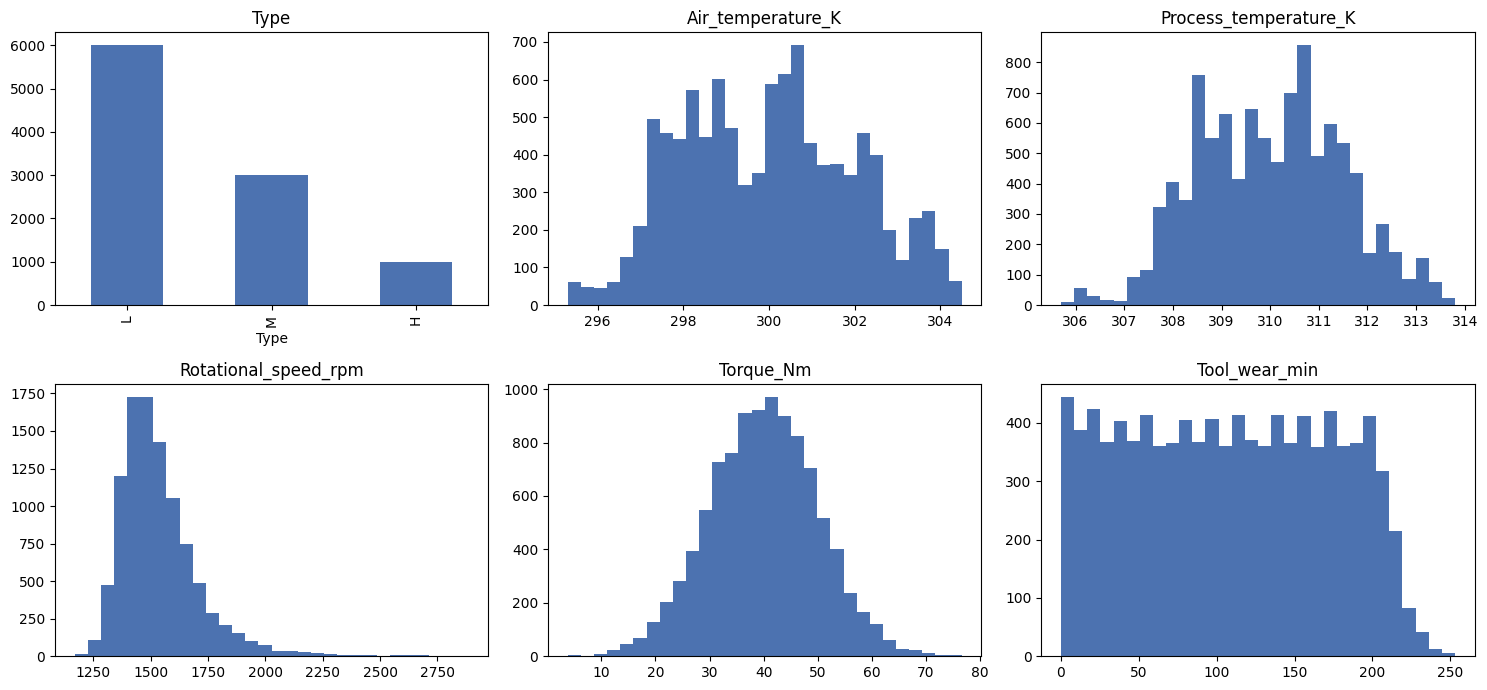

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    if col == "Type":
        df["Type"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
    else:
        ax.hist(df[col], bins=30, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout(); plt.show()


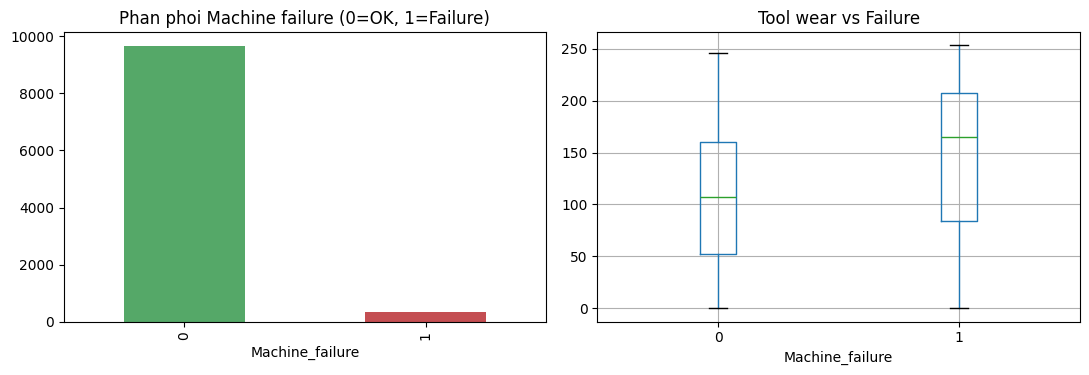

Ty le Machine_failure=1: 3.39 %


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET_COL].value_counts().plot(kind="bar", ax=ax[0], color=["#55A868", "#C44E52"])
ax[0].set_title("Phan phoi Machine failure (0=OK, 1=Failure)")

for col in ["Tool_wear_min", "Torque_Nm"]:
    pass
df.boxplot(column="Tool_wear_min", by=TARGET_COL, ax=ax[1])
ax[1].set_title("Tool wear vs Failure")
plt.suptitle("")
plt.tight_layout(); plt.show()

print("Ty le Machine_failure=1:", round(df[TARGET_COL].mean()*100, 2), "%")


## 04. ML Failure Prediction
Benchmark Logistic Regression / Random Forest / XGBoost (nếu có), chọn model cuối dựa trên val set.
Output quan trọng nhất là **P(Failure)**, không chỉ nhãn 0/1.


In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42),
}
if HAS_XGB:
    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.08,
        scale_pos_weight=pos_weight, eval_metric="logloss", random_state=42)
else:
    models["GradientBoosting"] = GradientBoostingClassifier(random_state=42)

bench_rows = []
fitted_models = {}
for name, mdl in models.items():
    mdl.fit(X_train_scaled, y_train)
    fitted_models[name] = mdl
    val_proba = mdl.predict_proba(X_val_scaled)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)
    bench_rows.append({
        "model": name,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, val_proba),
        "pr_auc": average_precision_score(y_val, val_proba),
    })

bench_df = pd.DataFrame(bench_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
bench_df


,model,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.577465,0.759259,0.656000,0.974139,0.734490
1,RandomForest,0.530303,0.648148,0.583333,0.959178,0.468152
2,LogisticRegression,0.143750,0.851852,0.245989,0.892147,0.420481


In [10]:
# Chon model cuoi cung dua tren ROC-AUC tren validation set
FINAL_MODEL_NAME = bench_df.iloc[0]["model"]
final_model = fitted_models[FINAL_MODEL_NAME]
print("Model duoc chon:", FINAL_MODEL_NAME)


Model duoc chon: XGBoost


## 05. ML Evaluation
Precision, Recall, F1, ROC-AUC, PR-AUC, Confusion Matrix trên **test set**.


              precision    recall  f1-score   support

           0      0.992     0.983     0.988      1932
           1      0.619     0.765     0.684        68

    accuracy                          0.976      2000
   macro avg      0.805     0.874     0.836      2000
weighted avg      0.979     0.976     0.977      2000

ROC-AUC: 0.9697
PR-AUC : 0.7877


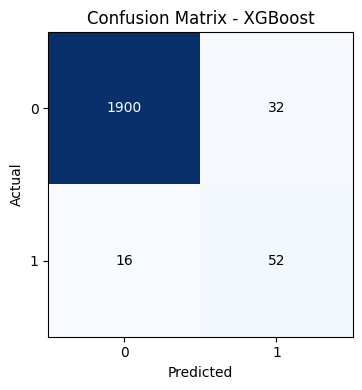

In [11]:
test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print(classification_report(y_test, test_pred, digits=3, zero_division=0))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, test_proba), 4))

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {FINAL_MODEL_NAME}")
plt.tight_layout(); plt.show()


## 06. Define DSS Criteria
Criteria của DSS lấy trực tiếp từ AI4I + output ML, **không thêm feature ngoài**:

| Criterion | Nguồn | Ý nghĩa |
|---|---|---|
| C1 - Failure Probability | Output ML | Quan trọng nhất |
| C2 - Tool Wear | AI4I | Độ mòn dụng cụ |
| C3 - Torque | AI4I | Mô-men xoắn |
| C4 - Process Temperature | AI4I | Nhiệt độ quá trình |
| C5 - Rotational Speed | AI4I | Tốc độ quay |
| C6 - Air Temperature | AI4I | Nhiệt độ môi trường |

Tất cả criteria đều được coi là **benefit criteria đối với "mức độ ưu tiên bảo trì"**: giá trị càng cao → máy càng cần được ưu tiên bảo trì.


In [12]:
CRITERIA_COLS = ["Failure_Probability", "Tool_wear_min", "Torque_Nm",
                  "Process_temperature_K", "Rotational_speed_rpm", "Air_temperature_K"]

def build_criteria_frame(X_raw_df, failure_proba):
    """Ghep P(Failure) tu ML + 5 sensor features (dang raw, chua scale) thanh DSS criteria matrix."""
    out = pd.DataFrame({
        "Failure_Probability": failure_proba,
        "Tool_wear_min": X_raw_df["Tool_wear_min"].values,
        "Torque_Nm": X_raw_df["Torque_Nm"].values,
        "Process_temperature_K": X_raw_df["Process_temperature_K"].values,
        "Rotational_speed_rpm": X_raw_df["Rotational_speed_rpm"].values,
        "Air_temperature_K": X_raw_df["Air_temperature_K"].values,
    }, index=X_raw_df.index)
    return out[CRITERIA_COLS]

val_criteria = build_criteria_frame(X_val, final_model.predict_proba(X_val_scaled)[:, 1])
val_criteria.head()


,Failure_Probability,Tool_wear_min,Torque_Nm,Process_temperature_K,Rotational_speed_rpm,Air_temperature_K
1267,0.002649,43,38.7,309.6,1549,298.1
5085,0.023379,61,56.0,313.0,1377,304.0
440,0.000847,54,39.2,308.5,1389,297.4
3445,0.117441,208,36.1,310.6,1599,301.6
1693,0.000300,26,27.8,307.5,1683,298.0


## 07. AHP Weight Calibration (data-driven / calibrated AHP)

> *"AHP criteria weights are calibrated using the historical AI4I dataset and evaluated against observed
> machine failure outcomes."*  Đây **không phải AHP thuần túy** (pairwise comparison chuyên gia) mà là
> **data-driven / calibrated AHP**: trọng số w = [w1..w6] (Σw=1, w≥0) được tối ưu sao cho **composite
> risk score = Σ wi·criterion_i (đã min-max normalize)** phân biệt tốt nhất Machine Failure trên **validation set**
> (tối đa hóa ROC-AUC của composite score so với nhãn thật).


In [13]:
def minmax_normalize(df_crit, ref_min=None, ref_max=None):
    ref_min = df_crit.min() if ref_min is None else ref_min
    ref_max = df_crit.max() if ref_max is None else ref_max
    return (df_crit - ref_min) / (ref_max - ref_min + 1e-9), ref_min, ref_max

val_norm, crit_min, crit_max = minmax_normalize(val_criteria)

# Initial (expert-like) AHP weights - vi du ban dau, se duoc calibrate lai
init_weights = np.array([0.38, 0.24, 0.16, 0.10, 0.07, 0.05])
init_weights = init_weights / init_weights.sum()

def neg_auc_of_weighted_score(w, norm_df, y_true):
    w = np.abs(w); w = w / w.sum()
    score = norm_df.values @ w
    try:
        return -roc_auc_score(y_true, score)
    except ValueError:
        return 0.0

constraints = ({"type": "eq", "fun": lambda w: np.sum(np.abs(w)) - 1.0},)
bounds = [(0.0, 1.0)] * len(CRITERIA_COLS)

opt = minimize(neg_auc_of_weighted_score, x0=init_weights, args=(val_norm, y_val),
               method="SLSQP", bounds=bounds, constraints=constraints,
               options={"maxiter": 300, "ftol": 1e-9})

calibrated_weights = np.abs(opt.x)
calibrated_weights = calibrated_weights / calibrated_weights.sum()

ahp_weights = pd.Series(calibrated_weights, index=CRITERIA_COLS).sort_values(ascending=False)
print("AUC voi weight ban dau  :", round(-neg_auc_of_weighted_score(init_weights, val_norm, y_val), 4))
print("AUC voi weight calibrate:", round(-neg_auc_of_weighted_score(calibrated_weights, val_norm, y_val), 4))
ahp_weights


AUC voi weight ban dau  : 0.9649
AUC voi weight calibrate: 0.9649


Failure_Probability      0.38
Tool_wear_min            0.24
Torque_Nm                0.16
Process_temperature_K    0.10
Rotational_speed_rpm     0.07
Air_temperature_K        0.05
dtype: float64

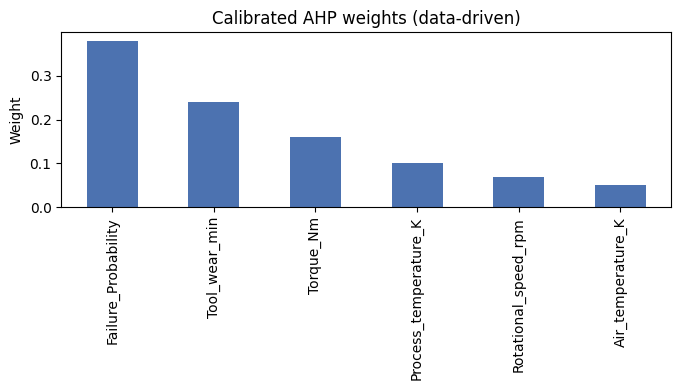

In [14]:
ax = ahp_weights.plot(kind="bar", color="#4C72B0", figsize=(7,4))
ax.set_title("Calibrated AHP weights (data-driven)")
ax.set_ylabel("Weight")
plt.tight_layout(); plt.show()


## 08. Build DSS Feature Matrix (Decision Matrix)
Với mỗi máy: `[Failure_Probability, Tool_wear, Torque, Process_temp, Rotational_speed, Air_temp]`.


In [15]:
test_failure_proba = final_model.predict_proba(X_test_scaled)[:, 1]
test_criteria = build_criteria_frame(X_test, test_failure_proba)
print("Decision matrix (test set) - vi du 5 dong dau:")
test_criteria.head()


Decision matrix (test set) - vi du 5 dong dau:


,Failure_Probability,Tool_wear_min,Torque_Nm,Process_temperature_K,Rotational_speed_rpm,Air_temperature_K
2997,0.382459,153,62.7,309.8,1345,300.5
4871,0.000590,135,40.1,312.4,1513,303.7
3858,0.201092,209,37.6,311.4,1559,302.5
951,0.006450,60,35.8,306.3,1509,295.6
6463,0.133190,102,60.4,310.0,1358,300.5


## 09. TOPSIS
Normalization → apply calibrated AHP weights → Positive/Negative Ideal Solution → Distance → TOPSIS Score
(TOPSIS score = **Maintenance Priority / Risk Score**, khác với P(Failure) của ML).


In [16]:
def topsis_score(criteria_df, weights, ref_min=None, ref_max=None):
    """Tat ca criteria la benefit-type doi voi 'muc do uu tien bao tri'."""
    norm, rmin, rmax = minmax_normalize(criteria_df, ref_min, ref_max)
    weighted = norm.values * weights.values  # (n, k)

    pis = weighted.max(axis=0)  # ideal: risk cao nhat -> uu tien cao nhat
    nis = weighted.min(axis=0)  # anti-ideal: risk thap nhat

    dist_pos = np.sqrt(((weighted - pis) ** 2).sum(axis=1))
    dist_neg = np.sqrt(((weighted - nis) ** 2).sum(axis=1))

    score = dist_neg / (dist_pos + dist_neg + 1e-12)
    return pd.Series(score, index=criteria_df.index, name="TOPSIS_Score")

test_topsis = topsis_score(test_criteria, ahp_weights, crit_min, crit_max)
val_topsis = topsis_score(val_criteria, ahp_weights, crit_min, crit_max)

test_topsis.describe()


count    2000.000000
mean        0.288965
std         0.117049
min         0.094130
25%         0.211654
50%         0.271245
75%         0.332535
max         0.834575
Name: TOPSIS_Score, dtype: float64

## 10. Decision Engine
Ngưỡng phân loại NORMAL / MEDIUM / HIGH / CRITICAL được **calibrate trên validation set**
(dựa trên precision-recall curve của TOPSIS score so với Machine Failure thật), thay vì chọn tùy tiện.


In [17]:
def calibrate_thresholds(scores, y_true, recall_targets=(0.95, 0.75, 0.50)):
    """recall_targets tuong ung nguong (thap->cao): [t_medium, t_high, t_critical]
    Voi moi recall target, tim threshold nho nhat sao cho recall >= target (cang inclusive
    thi threshold cang thap)."""
    precision, recall, thr = precision_recall_curve(y_true, scores)
    # precision_recall_curve tra ve threshold ung voi recall[:-1]/precision[:-1]
    recall_ = recall[:-1]; thr_ = thr
    order = np.argsort(thr_)
    thr_sorted, recall_sorted = thr_[order], recall_[order]

    chosen = []
    for target in recall_targets:
        idx_candidates = np.where(recall_sorted >= target)[0]
        if len(idx_candidates) == 0:
            chosen.append(thr_sorted[0])
        else:
            chosen.append(thr_sorted[idx_candidates[-1]])
    chosen = sorted(chosen)
    return chosen  # [t_medium, t_high, t_critical]

t_medium, t_high, t_critical = calibrate_thresholds(val_topsis.values, y_val.values)
print(f"Calibrated thresholds -> MEDIUM >= {t_medium:.3f} | HIGH >= {t_high:.3f} | CRITICAL >= {t_critical:.3f}")

def decision_engine(score, t_medium=t_medium, t_high=t_high, t_critical=t_critical):
    if score >= t_critical:
        return "CRITICAL", "Immediate Maintenance"
    elif score >= t_high:
        return "HIGH", "Schedule Maintenance"
    elif score >= t_medium:
        return "MEDIUM", "Inspection"
    else:
        return "NORMAL", "Continue Operation"


Calibrated thresholds -> MEDIUM >= 0.373 | HIGH >= 0.511 | CRITICAL >= 0.696


## 11. Explainable Decision
Với mỗi máy, giải thích các yếu tố đóng góp nhiều nhất vào priority score (tránh phát biểu nhân quả).


In [18]:
def explain_decision(criteria_row, weights, ref_min, ref_max, top_k=3):
    norm = (criteria_row - ref_min) / (ref_max - ref_min + 1e-9)
    contribution = norm * weights
    top = contribution.sort_values(ascending=False).head(top_k)
    labels = {
        "Failure_Probability": "High predicted failure probability",
        "Tool_wear_min": "High tool wear",
        "Torque_Nm": "High torque",
        "Process_temperature_K": "High process temperature",
        "Rotational_speed_rpm": "Rotational speed contributes to risk profile",
        "Air_temperature_K": "Air temperature contributes to risk profile",
    }
    return [labels.get(idx, idx) for idx in top.index]

# Vi du voi 1 may trong test set
example_idx = test_topsis.sort_values(ascending=False).index[0]
example_row = test_criteria.loc[example_idx]
level, action = decision_engine(test_topsis.loc[example_idx])
factors = explain_decision(example_row, ahp_weights, crit_min, crit_max)

print(f"Machine (test idx={example_idx})")
print(f"  Failure Probability : {example_row['Failure_Probability']:.2f}")
print(f"  TOPSIS Score         : {test_topsis.loc[example_idx]:.2f}")
print(f"  Risk Level           : {level}")
print(f"  Decision             : {action}")
print(f"  Main contributing factors:")
for f in factors:
    print(f"    - {f}")
print()
print('Luu y: cac yeu to tren la "contributes to priority score", KHONG phai quan he nhan qua voi failure.')


Machine (test idx=9664)
  Failure Probability : 0.99
  TOPSIS Score         : 0.83
  Risk Level           : CRITICAL
  Decision             : Immediate Maintenance
  Main contributing factors:
    - High predicted failure probability
    - High tool wear
    - High torque

Luu y: cac yeu to tren la "contributes to priority score", KHONG phai quan he nhan qua voi failure.


## 12. DSS Evaluation (offline)
Machine Failure chỉ dùng ở đây để **đánh giá**, không đi vào decision pipeline lúc runtime.


In [19]:
dss_eval = test_criteria.copy()
dss_eval["TOPSIS_Score"] = test_topsis
dss_eval["Machine_failure"] = y_test.values
dss_eval["Risk_Level"] = dss_eval["TOPSIS_Score"].apply(lambda s: decision_engine(s)[0])
dss_eval["Decision"] = dss_eval["TOPSIS_Score"].apply(lambda s: decision_engine(s)[1])

is_high_critical = dss_eval["Risk_Level"].isin(["HIGH", "CRITICAL"])
actual_failure = dss_eval["Machine_failure"] == 1

recall_high_critical = (is_high_critical & actual_failure).sum() / max(actual_failure.sum(), 1)
false_alarm_rate = (is_high_critical & ~actual_failure).sum() / max((~actual_failure).sum(), 1)
missed_failure_rate = (~is_high_critical & actual_failure).sum() / max(actual_failure.sum(), 1)
precision_high_critical = (is_high_critical & actual_failure).sum() / max(is_high_critical.sum(), 1)

print(f"Recall cua Machine Failure trong nhom HIGH/CRITICAL : {recall_high_critical:.3f}")
print(f"False Alarm Rate (OK bi xep HIGH/CRITICAL)          : {false_alarm_rate:.3f}")
print(f"Missed Failure Rate (Failure nhung khong bi flag)    : {missed_failure_rate:.3f}")
print(f"Precision cua quyet dinh HIGH/CRITICAL               : {precision_high_critical:.3f}")

print("\nPhan bo Risk Level:")
print(dss_eval["Risk_Level"].value_counts())

print("\nCheo Risk Level x Machine_failure:")
print(pd.crosstab(dss_eval["Risk_Level"], dss_eval["Machine_failure"]))


Recall cua Machine Failure trong nhom HIGH/CRITICAL : 0.779
False Alarm Rate (OK bi xep HIGH/CRITICAL)          : 0.020
Missed Failure Rate (Failure nhung khong bi flag)    : 0.221
Precision cua quyet dinh HIGH/CRITICAL               : 0.576

Phan bo Risk Level:
Risk_Level
NORMAL      1758
MEDIUM       150
CRITICAL      52
HIGH          40
Name: count, dtype: int64

Cheo Risk Level x Machine_failure:
Machine_failure     0   1
Risk_Level               
CRITICAL           14  38
HIGH               25  15
MEDIUM            141   9
NORMAL           1752   6


## 13. Save DSS Components
Lưu preprocessor, ML model, AHP weights, cấu hình TOPSIS (min/max), decision thresholds.
Ở **online phase**, hệ thống chỉ cần load lại các file này, **không đọc lại AI4I**.


In [20]:
joblib.dump(type_encoder, f"{ARTIFACT_DIR}/type_encoder.joblib")
joblib.dump(scaler, f"{ARTIFACT_DIR}/scaler.joblib")
joblib.dump(final_model, f"{ARTIFACT_DIR}/ml_model.joblib")

ahp_weights.to_json(f"{ARTIFACT_DIR}/ahp_weights.json")
crit_min.to_json(f"{ARTIFACT_DIR}/criteria_min.json")
crit_max.to_json(f"{ARTIFACT_DIR}/criteria_max.json")

with open(f"{ARTIFACT_DIR}/decision_thresholds.json", "w") as f:
    json.dump({"t_medium": float(t_medium), "t_high": float(t_high), "t_critical": float(t_critical),
               "final_model": FINAL_MODEL_NAME, "data_source": DATA_SOURCE}, f, indent=2)

print("Da luu DSS components vao thu muc:", ARTIFACT_DIR)
os.listdir(ARTIFACT_DIR)


Da luu DSS components vao thu muc: dss_artifacts


['criteria_max.json',
 'criteria_min.json',
 'ahp_weights.json',
 'type_encoder.joblib',
 'decision_thresholds.json',
 'ml_model.joblib',
 'scaler.joblib']

---
## 14. ONLINE PHASE - END-TO-END DEMO

Từ đây trở đi notebook mô phỏng **runtime**: chỉ load lại các artifact đã lưu ở trên,
**không đụng đến AI4I dataset gốc**. User nhập `MachineInput` (Type + 5 sensor values) cho từng máy,
hệ thống chạy qua `ML -> DSS criteria -> AHP(saved weights) -> TOPSIS -> Decision Engine -> Explanation`.


In [21]:
# 14.1 Load lai cac DSS component da luu (mo phong runtime, doc lai tu disk)
rt_type_encoder = joblib.load(f"{ARTIFACT_DIR}/type_encoder.joblib")
rt_scaler = joblib.load(f"{ARTIFACT_DIR}/scaler.joblib")
rt_model = joblib.load(f"{ARTIFACT_DIR}/ml_model.joblib")
rt_ahp_weights = pd.read_json(f"{ARTIFACT_DIR}/ahp_weights.json", typ="series")
rt_crit_min = pd.read_json(f"{ARTIFACT_DIR}/criteria_min.json", typ="series")
rt_crit_max = pd.read_json(f"{ARTIFACT_DIR}/criteria_max.json", typ="series")
with open(f"{ARTIFACT_DIR}/decision_thresholds.json") as f:
    rt_thresholds = json.load(f)

print("Da load DSS runtime components. Model:", rt_thresholds["final_model"],
      "| Data source luc train:", rt_thresholds["data_source"])


Da load DSS runtime components. Model: XGBoost | Data source luc train: kaggle_real


In [22]:
from dataclasses import dataclass

@dataclass
class MachineInput:
    machine_id: str
    type: str            # 'L' / 'M' / 'H'
    air_temperature: float     # K
    process_temperature: float # K
    rotational_speed: float    # rpm
    torque: float               # Nm
    tool_wear: float             # min

def process_machine(m: MachineInput):
    """Runtime pipeline cho 1 may: Type+5 sensor -> Preprocess -> ML -> DSS criteria -> AHP/TOPSIS -> Decision."""
    raw = pd.DataFrame([{
        "Type": m.type,
        "Air_temperature_K": m.air_temperature,
        "Process_temperature_K": m.process_temperature,
        "Rotational_speed_rpm": m.rotational_speed,
        "Torque_Nm": m.torque,
        "Tool_wear_min": m.tool_wear,
    }])

    enc = raw.copy()
    enc["Type"] = rt_type_encoder.transform(raw[["Type"]])
    scaled = pd.DataFrame(rt_scaler.transform(enc[FEATURE_COLS]), columns=FEATURE_COLS)

    failure_proba = float(rt_model.predict_proba(scaled)[:, 1][0])

    criteria_row = pd.Series({
        "Failure_Probability": failure_proba,
        "Tool_wear_min": m.tool_wear,
        "Torque_Nm": m.torque,
        "Process_temperature_K": m.process_temperature,
        "Rotational_speed_rpm": m.rotational_speed,
        "Air_temperature_K": m.air_temperature,
    })[CRITERIA_COLS]

    return failure_proba, criteria_row

def decision_engine_rt(score):
    t_m, t_h, t_c = rt_thresholds["t_medium"], rt_thresholds["t_high"], rt_thresholds["t_critical"]
    if score >= t_c:
        return "CRITICAL", "Immediate Maintenance"
    elif score >= t_h:
        return "HIGH", "Schedule Maintenance"
    elif score >= t_m:
        return "MEDIUM", "Inspection"
    return "NORMAL", "Continue Operation"

print("Runtime pipeline san sang.")


Runtime pipeline san sang.


### 14.2 Sinh giả lập ~10 máy để demo
Vì demo không đọc lại AI4I, ta sinh ngẫu nhiên 10 `MachineInput` với thông số hợp lý (trong khoảng giá trị
thường gặp của AI4I) để minh hoạ end-to-end pipeline + bài toán xếp hạng ưu tiên đa máy.


In [23]:
def generate_demo_machines(n=10, seed=7):
    rng = np.random.default_rng(seed)
    machines = []
    for i in range(n):
        t = rng.choice(["L", "M", "H"], p=[0.6, 0.3, 0.1])
        air_t = rng.normal(300, 2)
        proc_t = air_t + rng.normal(10, 1.2)
        speed = float(rng.normal(1538, 220))
        torque = float(rng.normal(40, 12))
        wear = float(rng.uniform(0, 253))
        # de demo co ca may binh thuong lan may rui ro cao, boost mot vai may
        if i < 3:
            wear = float(rng.uniform(180, 253))
            torque = float(rng.uniform(55, 76))
        machines.append(MachineInput(
            machine_id=f"M{i+1:03d}", type=str(t),
            air_temperature=round(air_t, 1), process_temperature=round(proc_t, 1),
            rotational_speed=round(max(speed, 1000), 0), torque=round(max(torque, 3), 1),
            tool_wear=round(max(wear, 0), 0)))
    return machines

demo_machines = generate_demo_machines(n=10)
pd.DataFrame([m.__dict__ for m in demo_machines])


,machine_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear
0,M001,M,300.6,310.3,1342.0,72.2,180.0
1,M002,M,298.8,309.3,1617.0,66.6,217.0
2,M003,H,299.1,306.8,1254.0,55.9,225.0
3,M004,L,299.6,306.6,1419.0,39.4,130.0
4,M005,L,299.0,307.9,1360.0,52.7,93.0
5,M006,L,301.8,311.1,1513.0,41.3,129.0
6,M007,M,300.2,311.8,1198.0,50.3,128.0
7,M008,M,304.0,314.9,1274.0,40.9,82.0
8,M009,L,301.4,311.3,1685.0,57.3,153.0
9,M010,M,299.1,309.2,1277.0,33.0,102.0


### 14.3 Chạy pipeline cho toàn bộ máy + TOPSIS Global Ranking

In [24]:
rows, criteria_rows = [], []
for m in demo_machines:
    proba, crit_row = process_machine(m)
    rows.append({"Machine": m.machine_id, "Failure_Probability": proba})
    criteria_rows.append(crit_row)

demo_criteria = pd.DataFrame(criteria_rows)
demo_criteria.index = [m.machine_id for m in demo_machines]

demo_topsis = topsis_score(demo_criteria, rt_ahp_weights, rt_crit_min, rt_crit_max)

results = demo_criteria.copy()
results["TOPSIS_Score"] = demo_topsis
results[["Risk_Level", "Decision"]] = results["TOPSIS_Score"].apply(
    lambda s: pd.Series(decision_engine_rt(s)))
results = results.sort_values("TOPSIS_Score", ascending=False)
results.insert(0, "Priority", range(1, len(results) + 1))

results[["Priority", "Failure_Probability", "TOPSIS_Score", "Risk_Level", "Decision"]]


,Priority,Failure_Probability,TOPSIS_Score,Risk_Level,Decision
M002,1,0.999610,0.837547,CRITICAL,Immediate Maintenance
M001,2,0.999548,0.836949,CRITICAL,Immediate Maintenance
M003,3,0.303966,0.399228,MEDIUM,Inspection
M008,4,0.074408,0.231568,NORMAL,Continue Operation
M009,5,0.002163,0.221651,NORMAL,Continue Operation
M007,6,0.001008,0.185679,NORMAL,Continue Operation
M006,7,0.000736,0.167086,NORMAL,Continue Operation
M004,8,0.006065,0.111502,NORMAL,Continue Operation
M005,9,0.003843,0.104224,NORMAL,Continue Operation
M010,10,0.001251,0.086723,NORMAL,Continue Operation


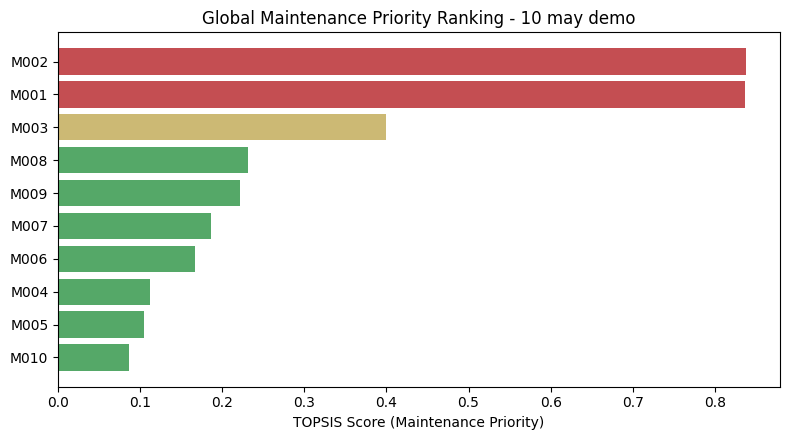

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = results["Risk_Level"].map({"CRITICAL": "#C44E52", "HIGH": "#DD8452",
                                     "MEDIUM": "#CCB974", "NORMAL": "#55A868"})
ax.barh(results.index[::-1], results["TOPSIS_Score"][::-1], color=colors[::-1])
ax.set_xlabel("TOPSIS Score (Maintenance Priority)")
ax.set_title("Global Maintenance Priority Ranking - 10 may demo")
plt.tight_layout(); plt.show()


### 14.4 Explainable Decision cho máy ưu tiên cao nhất

In [26]:
top_machine = results.index[0]
top_row = demo_criteria.loc[top_machine]
level, action = decision_engine_rt(results.loc[top_machine, "TOPSIS_Score"])
factors = explain_decision(top_row, rt_ahp_weights, rt_crit_min, rt_crit_max)

print(f"Machine: {top_machine}")
print(f"  Failure Probability : {top_row['Failure_Probability']:.2f}")
print(f"  TOPSIS Score         : {results.loc[top_machine, 'TOPSIS_Score']:.2f}")
print(f"  Risk Level            : {level}")
print(f"  Decision               : {action}")
print("  Main contributing factors:")
for f in factors:
    print(f"    - {f}")
print()
print('Luu y: day la cac yeu to "contributes to the maintenance priority score",')
print('khong phai phat bieu nhan qua kieu "X gay ra failure".')


Machine: M002
  Failure Probability : 1.00
  TOPSIS Score         : 0.84
  Risk Level            : CRITICAL
  Decision               : Immediate Maintenance
  Main contributing factors:
    - High predicted failure probability
    - High tool wear
    - High torque

Luu y: day la cac yeu to "contributes to the maintenance priority score",
khong phai phat bieu nhan qua kieu "X gay ra failure".


---
## 15. Tóm tắt

- **Offline**: AI4I 2020 (thật qua kagglehub, hoặc mô phỏng nếu không có mạng/credentials) → train + so sánh
  Logistic Regression / Random Forest / XGBoost → chọn model theo ROC-AUC → tính **P(Failure)**.
- **AHP**: 6 criteria (P(Failure) + 5 sensor AI4I) → trọng số **calibrated bằng dữ liệu**, tối ưu ROC-AUC
  trên validation set (data-driven / calibrated AHP, không phải AHP thuần túy).
- **TOPSIS**: kết hợp criteria đã chuẩn hoá + AHP weights → **Maintenance Priority Score**.
- **Decision Engine**: ngưỡng NORMAL/MEDIUM/HIGH/CRITICAL được **calibrate** bằng precision-recall curve
  trên validation set.
- **Online demo**: 10 máy giả lập → chạy qua pipeline đã lưu (không đọc lại AI4I) → **Global Priority Ranking**
  + Explainable Decision cho máy ưu tiên cao nhất.
